In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
df=pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\processed_data\enriched_data.csv", index_col='timestamp', parse_dates=['timestamp'])
print(df.shape)
print(df.head())

(26304, 5)
                            load  hour  day_of_week  month  year
timestamp                                                       
2023-01-01 00:00:00  5317.916667     0            6      1  2023
2023-01-01 01:00:00  5271.333333     1            6      1  2023
2023-01-01 02:00:00  5142.833333     2            6      1  2023
2023-01-01 03:00:00  5110.250000     3            6      1  2023
2023-01-01 04:00:00  5126.833333     4            6      1  2023


In [2]:
df.isnull().sum()

load           0
hour           0
day_of_week    0
month          0
year           0
dtype: int64

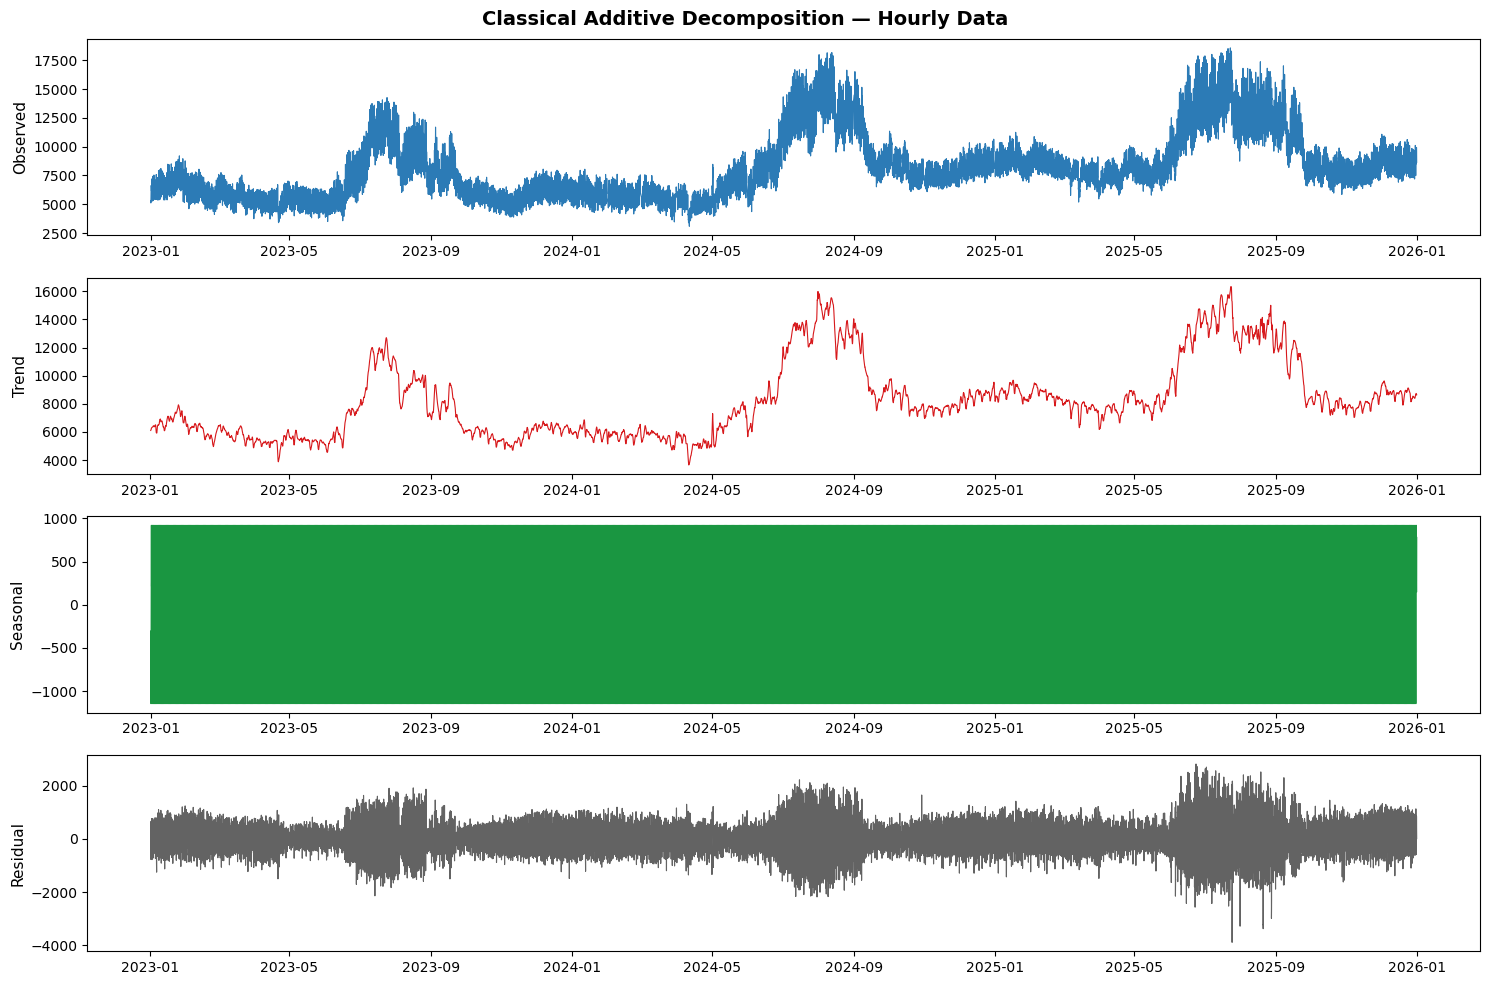

In [3]:


decomposition = seasonal_decompose(df['load'], 
                                   model='additive', 
                                   period=24)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(decomposition.observed, color='#2C7BB6', linewidth=0.8)
axes[0].set_ylabel('Observed', fontsize=11)

axes[1].plot(decomposition.trend, color='#D7191C', linewidth=0.8)
axes[1].set_ylabel('Trend', fontsize=11)

axes[2].plot(decomposition.seasonal, color='#1A9641', linewidth=0.8)
axes[2].set_ylabel('Seasonal', fontsize=11)

axes[3].plot(decomposition.resid, color='#636363', linewidth=0.8)
axes[3].set_ylabel('Residual', fontsize=11)

plt.suptitle('Classical Additive Decomposition — Hourly Data', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

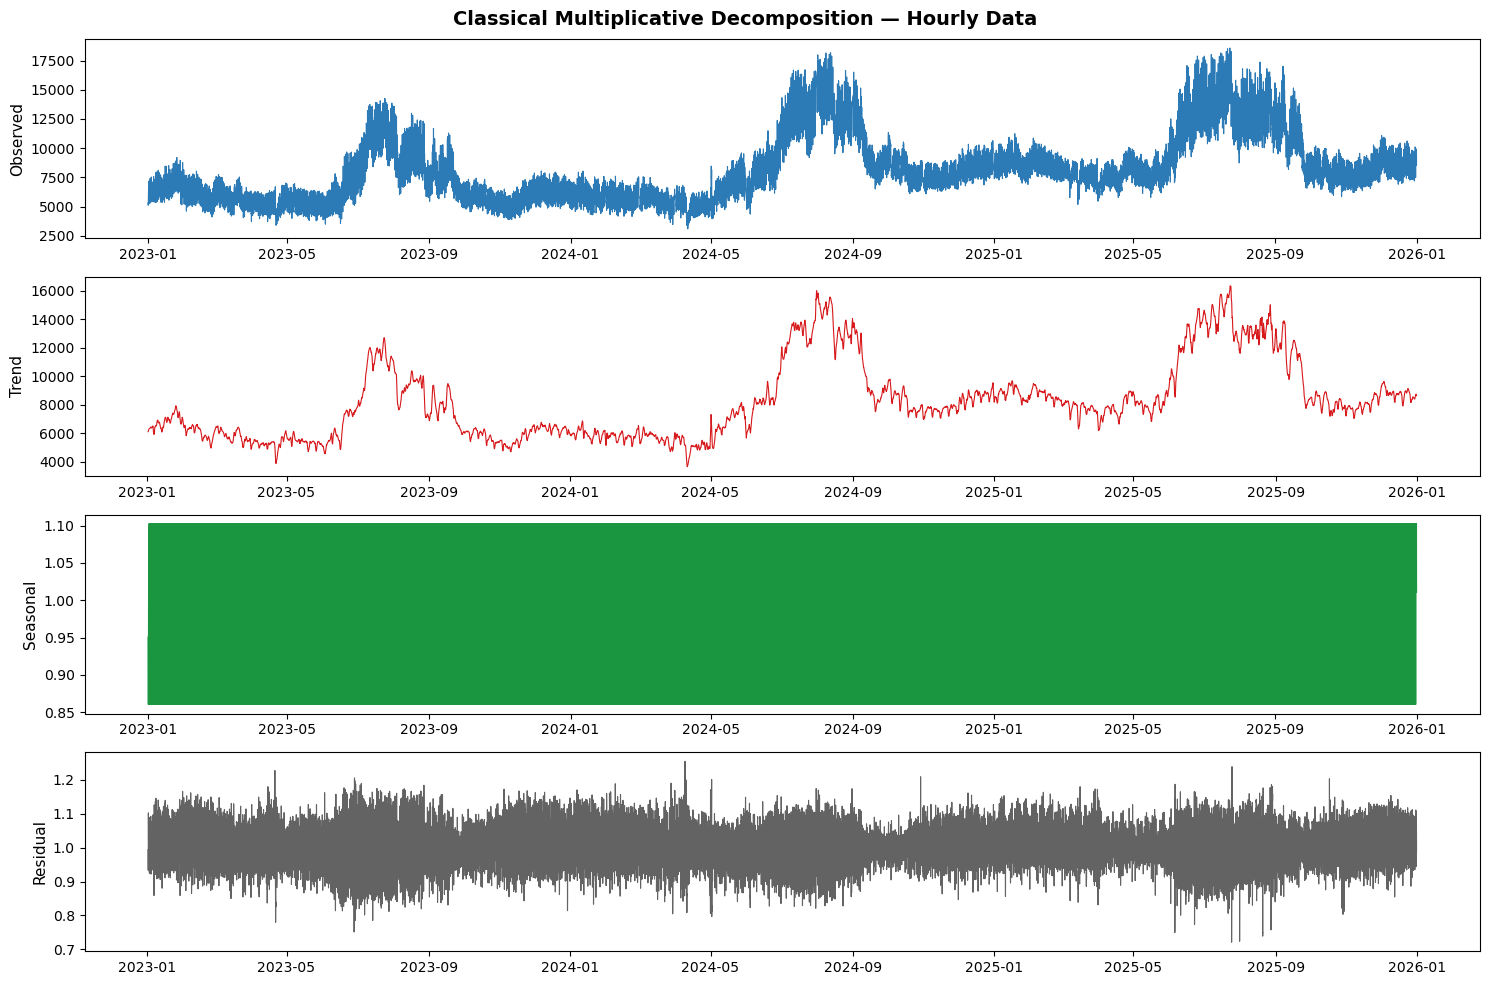

In [4]:


decomposition = seasonal_decompose(df['load'], 
                                   model='multiplicative', 
                                   period=24)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(decomposition.observed, color='#2C7BB6', linewidth=0.8)
axes[0].set_ylabel('Observed', fontsize=11)

axes[1].plot(decomposition.trend, color='#D7191C', linewidth=0.8)
axes[1].set_ylabel('Trend', fontsize=11)

axes[2].plot(decomposition.seasonal, color='#1A9641', linewidth=0.8)
axes[2].set_ylabel('Seasonal', fontsize=11)

axes[3].plot(decomposition.resid, color='#636363', linewidth=0.8)
axes[3].set_ylabel('Residual', fontsize=11)

plt.suptitle('Classical Multiplicative Decomposition — Hourly Data', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [2]:
z = df.loc[:"2025-06-30 23:00:00", "load"].dropna().asfreq("h")


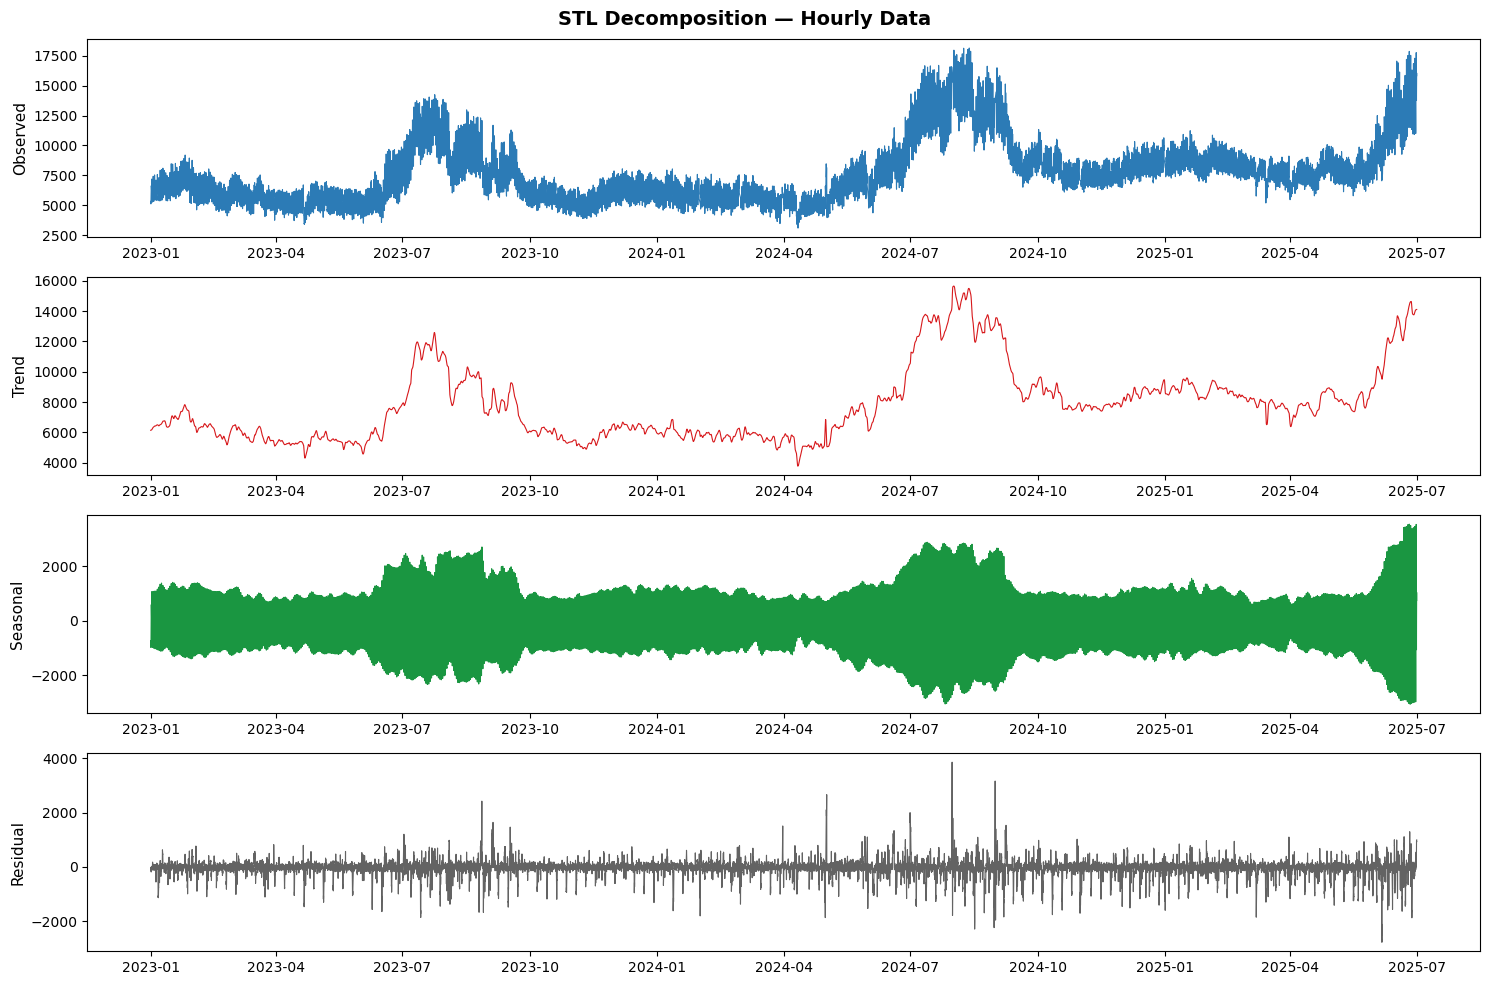

In [4]:
from statsmodels.tsa.seasonal import STL

stl = STL(z, period=24, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(result.observed, color='#2C7BB6', linewidth=0.8)
axes[0].set_ylabel('Observed', fontsize=11)

axes[1].plot(result.trend, color='#D7191C', linewidth=0.8)
axes[1].set_ylabel('Trend', fontsize=11)

axes[2].plot(result.seasonal, color='#1A9641', linewidth=0.8)
axes[2].set_ylabel('Seasonal', fontsize=11)

axes[3].plot(result.resid, color='#636363', linewidth=0.8)
axes[3].set_ylabel('Residual', fontsize=11)

plt.suptitle('STL Decomposition — Hourly Data', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


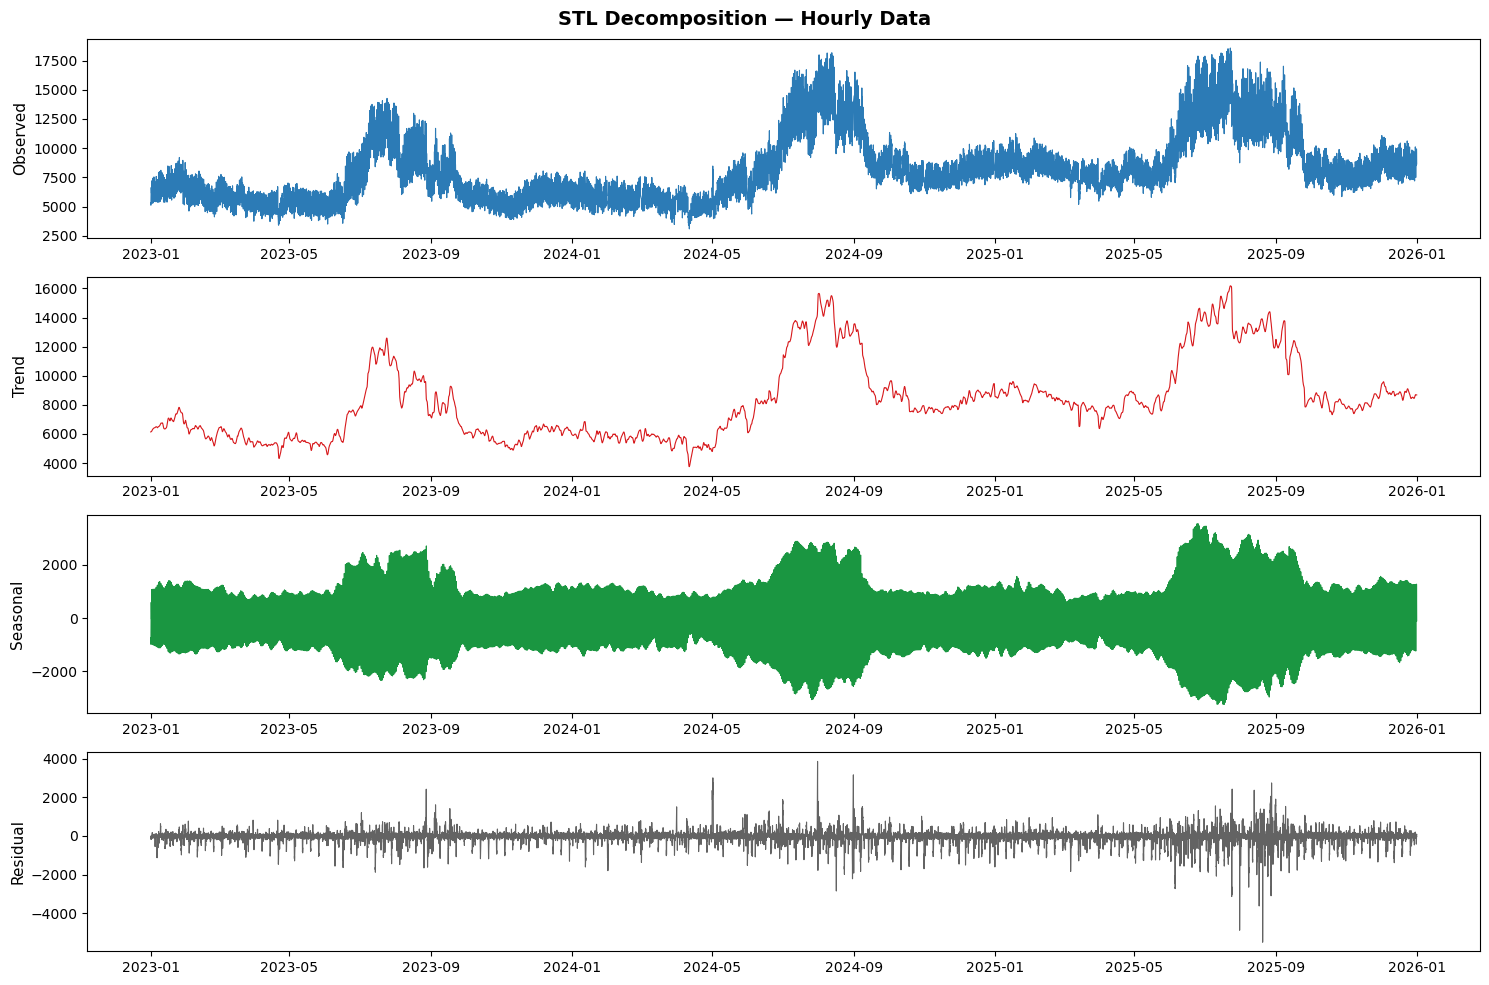

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['load'], period=24, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(result.observed, color='#2C7BB6', linewidth=0.8)
axes[0].set_ylabel('Observed', fontsize=11)

axes[1].plot(result.trend, color='#D7191C', linewidth=0.8)
axes[1].set_ylabel('Trend', fontsize=11)

axes[2].plot(result.seasonal, color='#1A9641', linewidth=0.8)
axes[2].set_ylabel('Seasonal', fontsize=11)

axes[3].plot(result.resid, color='#636363', linewidth=0.8)
axes[3].set_ylabel('Residual', fontsize=11)

plt.suptitle('STL Decomposition — Hourly Data', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
import numpy as np

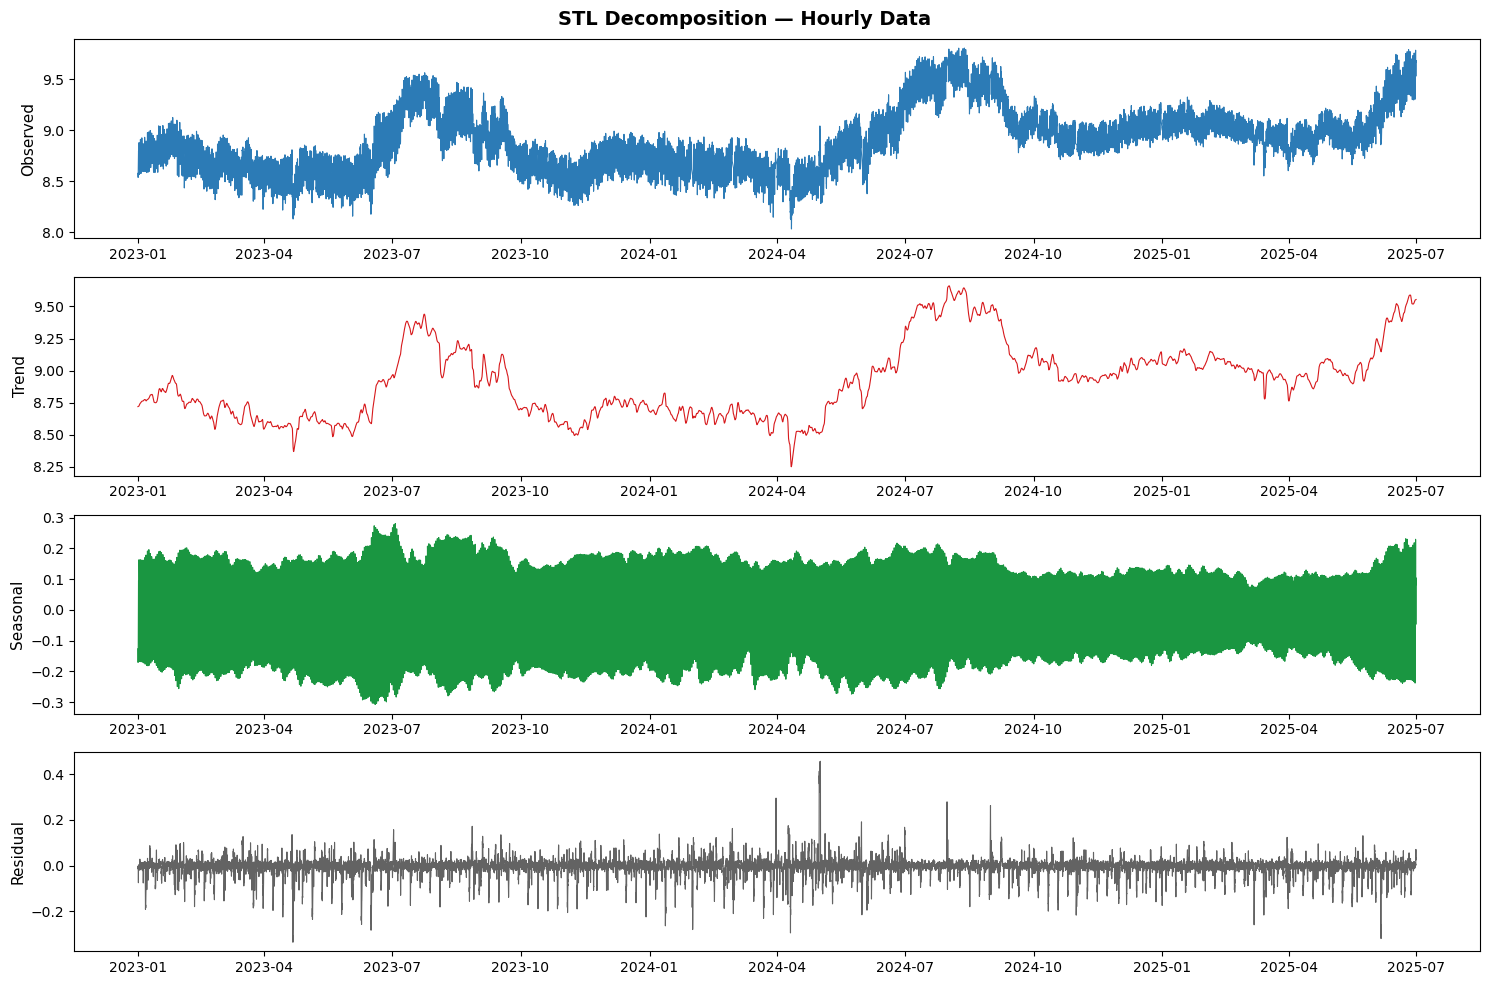

In [8]:
from statsmodels.tsa.seasonal import STL
l = np.log(z)
stl = STL(l, period=24, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(result.observed, color='#2C7BB6', linewidth=0.8)
axes[0].set_ylabel('Observed', fontsize=11)

axes[1].plot(result.trend, color='#D7191C', linewidth=0.8)
axes[1].set_ylabel('Trend', fontsize=11)

axes[2].plot(result.seasonal, color='#1A9641', linewidth=0.8)
axes[2].set_ylabel('Seasonal', fontsize=11)

axes[3].plot(result.resid, color='#636363', linewidth=0.8)
axes[3].set_ylabel('Residual', fontsize=11)

plt.suptitle('STL Decomposition — Hourly Data', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# ADF Test on quarter-hourly data
adf_result = adfuller(df['load'], autolag='AIC')
print('=== ADF Test ===')
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print(f'Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value:.4f}')

# KPSS Test on quarter-hourly data
kpss_result = kpss(df['load'], regression='c', nlags='auto')
print('\n=== KPSS Test ===')
print(f'KPSS Statistic: {kpss_result[0]:.4f}')
print(f'p-value: {kpss_result[1]:.4f}')
print(f'Critical Values:')
for key, value in kpss_result[3].items():
    print(f'   {key}: {value:.4f}')

=== ADF Test ===
ADF Statistic: -3.2678
p-value: 0.0164
Critical Values:
   1%: -3.4306
   5%: -2.8617
   10%: -2.5668

=== KPSS Test ===
KPSS Statistic: 8.3919
p-value: 0.0100
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


C:\Users\Top Prix\AppData\Local\Temp\ipykernel_504\4087729043.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df['load'], regression='c', nlags='auto')


In [12]:
# Remove daily seasonality (lag 24 for hourly)
df['consumption_diff'] = z.diff(24)

In [6]:
# ADF Test on quarter-hourly data
adf_result = adfuller(df['consumption_diff'].dropna(), autolag='AIC')
print('=== ADF Test ===')
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print(f'Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value:.4f}')

# KPSS Test on quarter-hourly data
kpss_result = kpss(df['consumption_diff'].dropna(), regression='c', nlags='auto')
print('\n=== KPSS Test ===')
print(f'KPSS Statistic: {kpss_result[0]:.4f}')
print(f'p-value: {kpss_result[1]:.4f}')
print(f'Critical Values:')
for key, value in kpss_result[3].items():
    print(f'   {key}: {value:.4f}')

=== ADF Test ===
ADF Statistic: -21.8895
p-value: 0.0000
Critical Values:
   1%: -3.4306
   5%: -2.8617
   10%: -2.5668

=== KPSS Test ===
KPSS Statistic: 0.0289
p-value: 0.1000
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


C:\Users\Top Prix\AppData\Local\Temp\ipykernel_504\3370779520.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df['consumption_diff'].dropna(), regression='c', nlags='auto')


KeyError: 'consumption_diff'

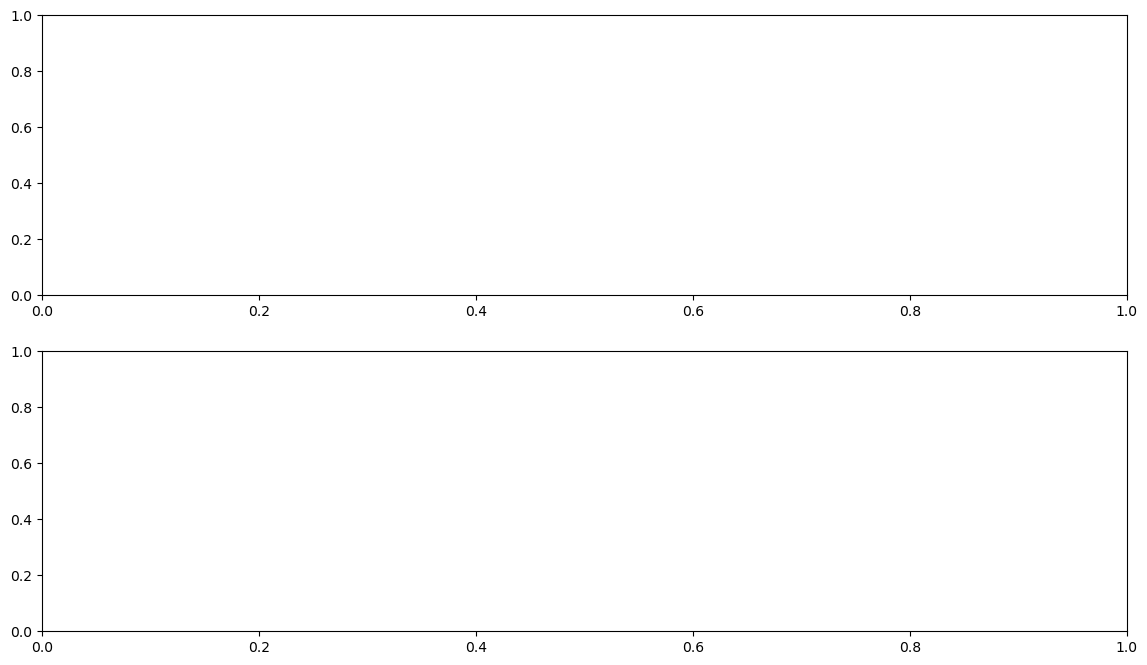

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df['consumption_diff'].dropna(), lags=200, 
         ax=axes[0], color='#2C7BB6')
axes[0].set_title('ACF — Seasonally Differenced Series (lag 24)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lags', fontsize=12)
axes[0].set_ylabel('ACF', fontsize=12)

plot_pacf(df['consumption_diff'].dropna(), lags=200, 
          ax=axes[1], color='#2C7BB6')
axes[1].set_title('PACF — Seasonally Differenced Series (lag 24)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lags', fontsize=12)
axes[1].set_ylabel('PACF', fontsize=12)

plt.tight_layout()
plt.show()

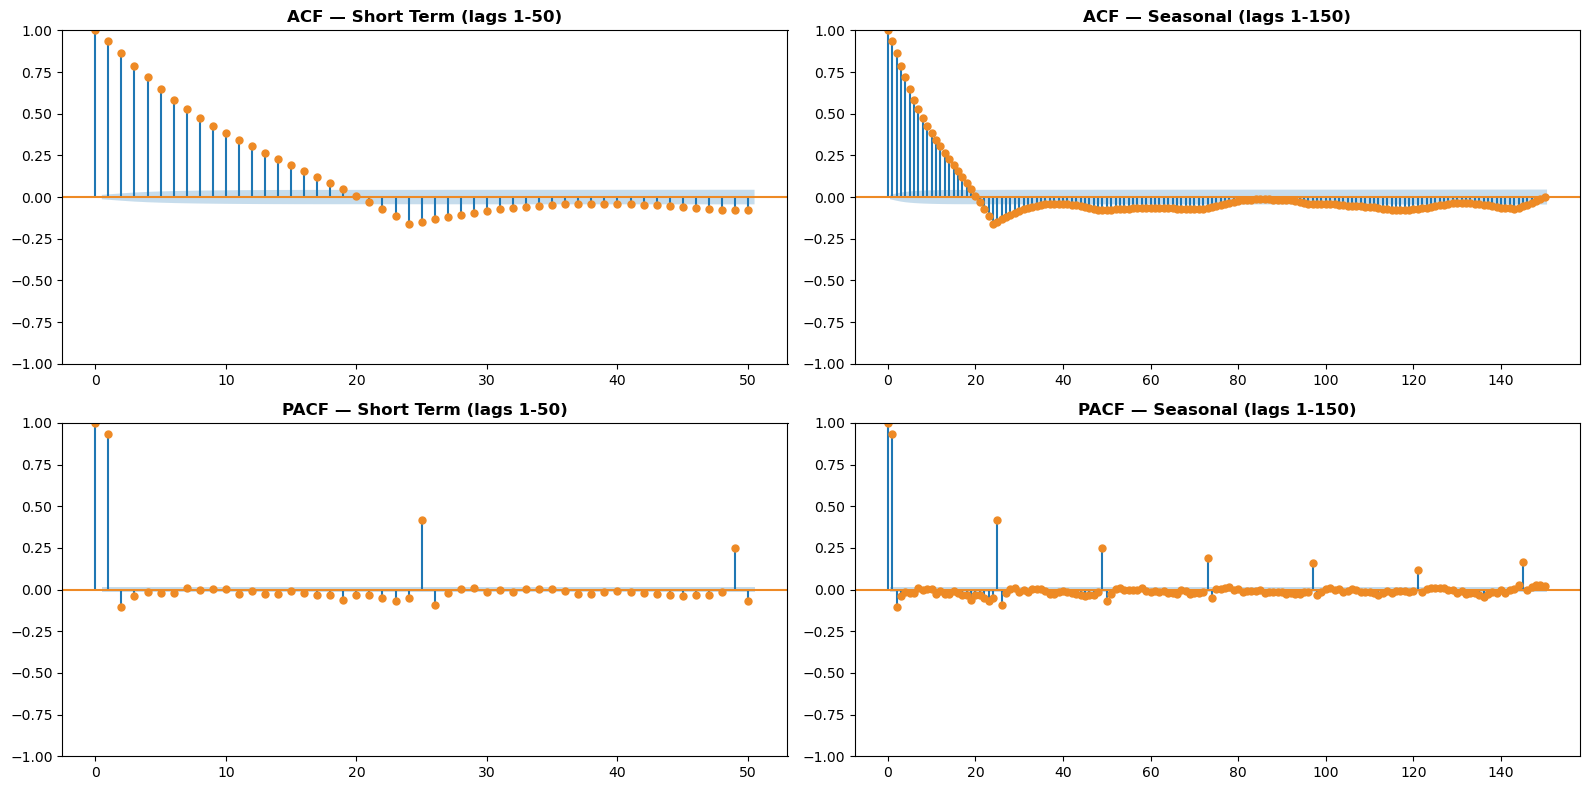

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Short term
plot_acf(df['consumption_diff'].dropna(), lags=50, ax=axes[0,0], color="#EE8A25")
axes[0,0].set_title('ACF — Short Term (lags 1-50)', fontweight='bold')

plot_pacf(df['consumption_diff'].dropna(), lags=50, ax=axes[1,0], color="#EE8A25")
axes[1,0].set_title('PACF — Short Term (lags 1-50)', fontweight='bold')

# Seasonal
plot_acf(df['consumption_diff'].dropna(), lags=150, ax=axes[0,1], color="#EE8A25")
axes[0,1].set_title('ACF — Seasonal (lags 1-150)', fontweight='bold')

plot_pacf(df['consumption_diff'].dropna(), lags=150, ax=axes[1,1], color="#EE8A25")
axes[1,1].set_title('PACF — Seasonal (lags 1-150)', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# series (already seasonally differenced if you used it that way)
z = df['load'].dropna()

# non-seasonal candidates
pq_candidates = [
    (1, 0, 0),
    (2, 0, 0),
    (3, 0, 0),
    (1, 0, 1),
    (2, 0, 1),
]

# seasonal candidates (P, D, Q, s)
seasonal_candidates = [
    (0, 1, 0, 24),
    (1, 1, 0, 24),  # main candidate
    (0, 1, 1, 24),
    (1, 1, 1, 24),
    (2, 1, 0, 24),  # just in case (your request)
]

rows = []

for order in pq_candidates:
    for seasonal_order in seasonal_candidates:
        try:
            model = SARIMAX(
                z,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit(disp=False)

            rows.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "aic": fit.aic,
                "bic": fit.bic
            })

        except Exception as e:
            rows.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "aic": None,
                "bic": None,
                "error": str(e)
            })

results_df = pd.DataFrame(rows).sort_values("aic", na_position="last")

print(results_df.head(10))

c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_mod

KeyboardInterrupt: 

In [2]:
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

z = df.loc[:"2025-06-30 23:00:00", "load"].dropna().asfreq("h")

candidates = [
    ((2, 0, 0), (0, 1, 0, 24)),
    ((2, 0, 1), (0, 1, 0, 24)),
    ((2, 0, 0), (1, 1, 0, 24)),
    ((2, 0, 1), (1, 1, 0, 24)),
    ((2, 0, 0), (0, 1, 1, 24)),
    ((2, 0, 1), (0, 1, 1, 24)),
]

rows = []

for order, seasonal_order in candidates:
    print(f"Fitting SARIMA{order}x{seasonal_order}...")
    try:
        fit = SARIMAX(
            z,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=50)

        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fit.aic,
            "bic": fit.bic
        })
        print(f"  done | AIC={fit.aic:.2f} | BIC={fit.bic:.2f}")

    except Exception as e:
        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": None,
            "bic": None,
            "error": str(e)
        })
        print(f"  failed | {e}")

results_df = pd.DataFrame(rows).sort_values("aic", na_position="last")
print(results_df)

Fitting SARIMA(2, 0, 0)x(0, 1, 0, 24)...
  done | AIC=294132.75 | BIC=294156.73
Fitting SARIMA(2, 0, 1)x(0, 1, 0, 24)...
  done | AIC=294086.66 | BIC=294118.63
Fitting SARIMA(2, 0, 0)x(1, 1, 0, 24)...
  done | AIC=289057.76 | BIC=289089.72
Fitting SARIMA(2, 0, 1)x(1, 1, 0, 24)...
  done | AIC=289022.36 | BIC=289062.32
Fitting SARIMA(2, 0, 0)x(0, 1, 1, 24)...
  done | AIC=285277.97 | BIC=285309.94
Fitting SARIMA(2, 0, 1)x(0, 1, 1, 24)...
  done | AIC=285250.42 | BIC=285290.38
       order seasonal_order            aic            bic
5  (2, 0, 1)  (0, 1, 1, 24)  285250.418206  285290.375240
4  (2, 0, 0)  (0, 1, 1, 24)  285277.970889  285309.936700
3  (2, 0, 1)  (1, 1, 0, 24)  289022.359318  289062.316352
2  (2, 0, 0)  (1, 1, 0, 24)  289057.756464  289089.722091
1  (2, 0, 1)  (0, 1, 0, 24)  294086.662238  294118.632259
0  (2, 0, 0)  (0, 1, 0, 24)  294132.749926  294156.727441
